# Context-Aware Prompting with LangGraph

## Theory

**Context-aware prompting** dynamically assembles relevant information — user profile,
retrieved documents, conversation history — into the prompt at runtime.

The model's answer is only as good as the context it receives.
Without context, it guesses. With context, it reasons from facts.

### The 5 context layers (assembled in order)

| Layer | What it carries | When it changes |
|---|---|---|
| System role | Who the model is, what it can do | Once per app |
| User profile | Name, plan, preferences, past behaviour | Once per session |
| Retrieved facts | Relevant docs/policies fetched for this query (RAG) | Every query |
| Conversation history | Prior turns in this session | Every turn |
| Current message | The actual user question | Every turn |

### Why LangGraph fits perfectly
Each layer of context is a **node** that enriches the state before the LLM call.
The state object carries everything forward — nothing is passed as raw arguments.
This makes the pipeline easy to test, debug, and extend.

### Scenario in this notebook
A customer support bot for a fictional SaaS product called **CloudBase**.
It knows the user's plan, fetches the right policy doc, and maintains
conversation memory — so it never asks what it already knows.

In [1]:
# ── Imports ───────────────────────────────────────────────
from typing import TypedDict, Optional, List
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from IPython.display import Image, display
from dotenv import load_dotenv
import os

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

llm = ChatOpenAI(model="gpt-4o", temperature=0.2)

In [2]:
# ── State ─────────────────────────────────────────────────
# The state carries ALL context through every node.
# Each node reads what it needs and writes what it produces.

class SupportState(TypedDict):
    # Input
    user_id: str                      # Who is asking
    user_message: str                 # What they asked

    # Context built up by nodes
    user_profile: Optional[dict]      # Name, plan, preferences
    retrieved_docs: Optional[str]     # Relevant policy / FAQ text
    conversation_history: List[dict]  # Previous turns [{role, content}]

    # Output
    response: Optional[str]           # Final answer

In [3]:
# ── Fake Data Sources ─────────────────────────────────────
# In production these would be real DB / vector store calls.
# Here we simulate them with dicts.

USER_DB = {
    "user_001": {
        "name": "Anil",
        "plan": "Pro",
        "seats": 10,
        "joined": "2023-06",
        "preferred_language": "English",
        "open_tickets": 1,
    },
    "user_002": {
        "name": "Priya",
        "plan": "Starter",
        "seats": 3,
        "joined": "2024-01",
        "preferred_language": "English",
        "open_tickets": 0,
    },
}

# Simulated knowledge base — key = topic keyword, value = policy snippet
KNOWLEDGE_BASE = {
    "refund": """
CloudBase Refund Policy:
- Pro plan: Full refund within 30 days of billing.
- Starter plan: Refund only within 7 days.
- Annual plans: Prorated refund after 30 days.
- To request: email billing@cloudbase.io with your invoice number.
""",
    "upgrade": """
CloudBase Upgrade Policy:
- Upgrades take effect immediately.
- You are billed the prorated difference for the current billing cycle.
- To upgrade: go to Settings > Billing > Change Plan.
- Downgrading takes effect at the next billing cycle.
""",
    "seats": """
CloudBase Seat Management:
- Pro plan: up to 50 seats. Starter: up to 5 seats.
- Adding seats: Settings > Team > Add Member.
- Each seat is billed at your plan's per-seat rate.
- Removing seats takes effect at the next billing cycle.
""",
    "api": """
CloudBase API Access:
- API available on Pro plan and above.
- Rate limit: 1000 requests/hour on Pro, 5000 on Enterprise.
- API keys: Settings > Developer > API Keys.
- Docs: docs.cloudbase.io/api
""",
    "default": """
CloudBase General Support:
- Support hours: Monday-Friday, 9am-6pm IST.
- Email: support@cloudbase.io
- Response time: Pro plan < 4 hours, Starter < 24 hours.
"""
}

In [4]:
# ── Node 1: load_user_profile ─────────────────────────────
# Fetches the user record from the database.
# This gives the LLM personal context — it can say "Hi Anil" and
# know the user is on the Pro plan without ever asking.

def load_user_profile(state: SupportState) -> SupportState:
    user_id = state["user_id"]
    profile = USER_DB.get(user_id, {
        "name": "Valued Customer",
        "plan": "Unknown",
        "seats": 0
    })
    print(f"[Node 1] Loaded profile for {profile['name']} ({profile['plan']} plan)")
    return {**state, "user_profile": profile}

In [5]:
# ── Node 2: retrieve_context ──────────────────────────────
# Simulates a RAG (Retrieval-Augmented Generation) lookup.
# In production: embed the query, vector-search a knowledge base,
# return the top-k chunks.
# Here: keyword match against our small KNOWLEDGE_BASE dict.

def retrieve_context(state: SupportState) -> SupportState:
    query = state["user_message"].lower()

    # Find the most relevant knowledge base entry
    matched_doc = KNOWLEDGE_BASE["default"]
    for keyword, doc in KNOWLEDGE_BASE.items():
        if keyword in query:
            matched_doc = doc
            print(f"[Node 2] Retrieved doc for topic: '{keyword}'")
            break
    else:
        print("[Node 2] No specific topic found — using general support doc")

    return {**state, "retrieved_docs": matched_doc}

In [6]:
# ── Node 3: generate_response ─────────────────────────────
# This is where context-aware prompting happens.
# We assemble ALL context layers into a single prompt:
#   1. System role (who the bot is)
#   2. User profile (personalised facts)
#   3. Retrieved docs (relevant policy/FAQ)
#   4. Conversation history (prior turns)
#   5. Current message (the actual question)

def generate_response(state: SupportState) -> SupportState:
    profile = state["user_profile"]
    docs     = state["retrieved_docs"]
    history  = state.get("conversation_history", [])
    question = state["user_message"]

    # ── Layer 1: System role ──────────────────────────────
    system_prompt = """You are Aria, a friendly and knowledgeable customer support agent for CloudBase.

Your behaviour:
- Always address the user by their first name
- Tailor your answer to their specific plan (they shouldn't have to repeat it)
- Base your answer strictly on the provided policy documentation
- If the policy does not cover their question, say so honestly
- Be concise — 3-5 sentences maximum unless steps are needed
- Never make up features, prices, or policies
"""

    # ── Layer 2: User profile context ────────────────────
    profile_context = f"""--- User Profile ---
Name: {profile['name']}
Current plan: {profile['plan']}
Seats: {profile['seats']}
Member since: {profile.get('joined', 'N/A')}
Open support tickets: {profile.get('open_tickets', 0)}
"""

    # ── Layer 3: Retrieved documentation ─────────────────
    docs_context = f"""--- Relevant Policy Documentation ---
{docs.strip()}
"""

    # ── Assemble system message (layers 1 + 2 + 3) ───────
    full_system = system_prompt + "\n" + profile_context + "\n" + docs_context

    # ── Layer 4: Conversation history ─────────────────────
    # Reconstruct prior turns as LangChain message objects
    messages = [SystemMessage(content=full_system)]

    for turn in history:
        if turn["role"] == "user":
            messages.append(HumanMessage(content=turn["content"]))
        elif turn["role"] == "assistant":
            messages.append(AIMessage(content=turn["content"]))

    # ── Layer 5: Current user message ─────────────────────
    messages.append(HumanMessage(content=question))

    print(f"[Node 3] Sending {len(messages)} messages to LLM "
          f"({len(history)} history turns + current message)")

    # ── LLM call ──────────────────────────────────────────
    result = llm.invoke(messages)

    return {**state, "response": result.content}

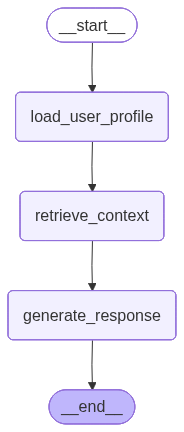

In [7]:
# ── Graph Construction ─────────────────────────────────────
def build_support_graph():
    builder = StateGraph(SupportState)

    builder.add_node("load_user_profile", load_user_profile)
    builder.add_node("retrieve_context",  retrieve_context)
    builder.add_node("generate_response", generate_response)

    builder.add_edge(START,               "load_user_profile")
    builder.add_edge("load_user_profile", "retrieve_context")
    builder.add_edge("retrieve_context",  "generate_response")
    builder.add_edge("generate_response", END)

    return builder.compile()


graph = build_support_graph()
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
# ── Multi-turn helper ─────────────────────────────────────
# Simulates a real conversation by accumulating history between turns.
# Each turn adds the question + answer to conversation_history,
# so the LLM remembers what was said.

class SupportSession:
    def __init__(self, user_id: str):
        self.user_id = user_id
        self.history = []  # Grows with each turn

    def ask(self, question: str) -> str:
        print(f"\n{'='*60}")
        print(f"User: {question}")
        print(f"History turns so far: {len(self.history)}")
        print('='*60)

        result = graph.invoke({
            "user_id": self.user_id,
            "user_message": question,
            "user_profile": None,
            "retrieved_docs": None,
            "conversation_history": self.history,
            "response": None,
        })

        answer = result["response"]

        # Accumulate history for next turn
        self.history.append({"role": "user",      "content": question})
        self.history.append({"role": "assistant", "content": answer})

        print(f"\nAria: {answer}")
        return answer

In [9]:
# ── Demo: Anil (Pro plan) — 3-turn conversation ───────────
# Watch how:
#  Turn 1 — Aria knows Anil's name and plan without being told
#  Turn 2 — Aria retrieves the correct refund policy for Pro plan
#  Turn 3 — Aria remembers from Turn 2 without the user repeating

session_anil = SupportSession(user_id="user_001")

session_anil.ask("Hi, I have a question about my account.")



User: Hi, I have a question about my account.
History turns so far: 0
[Node 1] Loaded profile for Anil (Pro plan)
[Node 2] No specific topic found — using general support doc
[Node 3] Sending 2 messages to LLM (0 history turns + current message)

Aria: Hi Anil, I'd be happy to help with your account question. Could you please provide a bit more detail about what you need assistance with?


"Hi Anil, I'd be happy to help with your account question. Could you please provide a bit more detail about what you need assistance with?"

In [13]:
session_anil.ask("Can I get a refund for this month's payment?")


User: Can I get a refund for this month's payment?
History turns so far: 6
[Node 1] Loaded profile for Anil (Pro plan)
[Node 2] Retrieved doc for topic: 'refund'
[Node 3] Sending 8 messages to LLM (6 history turns + current message)

Aria: Since you're on the Pro plan, Anil, you are eligible for a full refund if you request it within 30 days of billing. If you are within this timeframe, please email billing@cloudbase.io with your invoice number to initiate the refund process. Let me know if you need further assistance!


"Since you're on the Pro plan, Anil, you are eligible for a full refund if you request it within 30 days of billing. If you are within this timeframe, please email billing@cloudbase.io with your invoice number to initiate the refund process. Let me know if you need further assistance!"

In [10]:
# Turn 3: References the previous answer without re-stating it
session_anil.ask("What email should I send that refund request to?")


User: What email should I send that refund request to?
History turns so far: 2
[Node 1] Loaded profile for Anil (Pro plan)
[Node 2] Retrieved doc for topic: 'refund'
[Node 3] Sending 4 messages to LLM (2 history turns + current message)

Aria: Anil, for a refund request on your Pro plan, you should email billing@cloudbase.io with your invoice number. If it's within 30 days of billing, you are eligible for a full refund. Let me know if there's anything else you need!


"Anil, for a refund request on your Pro plan, you should email billing@cloudbase.io with your invoice number. If it's within 30 days of billing, you are eligible for a full refund. Let me know if there's anything else you need!"

In [11]:
# ── Demo: Priya (Starter plan) — same question, different answer ──
# Because the user profile is different, the refund policy window
# will be 7 days (Starter) not 30 days (Pro) — same graph, same question.

session_priya = SupportSession(user_id="user_002")

session_priya.ask("Can I get a refund for this month's payment?")


User: Can I get a refund for this month's payment?
History turns so far: 0
[Node 1] Loaded profile for Priya (Starter plan)
[Node 2] Retrieved doc for topic: 'refund'
[Node 3] Sending 2 messages to LLM (0 history turns + current message)

Aria: Hi Priya, since you're on the Starter plan, you are eligible for a refund only if you request it within 7 days of the billing date. If you're within this timeframe, please email billing@cloudbase.io with your invoice number to initiate the refund process. If it's been more than 7 days, unfortunately, a refund isn't possible according to our policy.


"Hi Priya, since you're on the Starter plan, you are eligible for a refund only if you request it within 7 days of the billing date. If you're within this timeframe, please email billing@cloudbase.io with your invoice number to initiate the refund process. If it's been more than 7 days, unfortunately, a refund isn't possible according to our policy."

In [12]:
# ── Demo: API question routed to correct doc ───────────────
session_anil.ask("How do I get my API key?")


User: How do I get my API key?
History turns so far: 4
[Node 1] Loaded profile for Anil (Pro plan)
[Node 2] Retrieved doc for topic: 'api'
[Node 3] Sending 6 messages to LLM (4 history turns + current message)

Aria: To get your API key, Anil, you need to navigate to the Settings section of your CloudBase account. From there, go to Developer and then API Keys. You'll find the option to generate or view your API key. If you have any trouble accessing it, feel free to let me know!


"To get your API key, Anil, you need to navigate to the Settings section of your CloudBase account. From there, go to Developer and then API Keys. You'll find the option to generate or view your API key. If you have any trouble accessing it, feel free to let me know!"

## What you just saw

| Behaviour | How it works |
|---|---|
| Bot greets user by name | `load_user_profile` injects name into system prompt |
| Knows plan without asking | Profile context carries `plan` field |
| Gives correct refund window per plan | Retrieved doc + profile combined in prompt |
| Remembers email from previous turn | `conversation_history` carries prior turns |
| Same question → different answer for Priya | Profile is user-specific, not hardcoded |
| Routes to API doc when asked about API | `retrieve_context` keyword match |

## Key design principles

**1. Context belongs in state, not in function args**
Every node reads from and writes to `SupportState`.
Nothing is passed as a raw string between nodes.
This makes each node independently testable.

**2. Separate retrieval from generation**
`retrieve_context` and `generate_response` are different nodes.
You can swap in a real vector store without touching the LLM node.

**3. History is explicit**
Conversation history is a list in state — you control what goes in,
what gets trimmed, and how it's formatted. No magic.

**4. System prompt is assembled at runtime**
The system prompt is not static — it's built fresh each turn from
live profile + fresh retrieved docs + current history.
This is what makes it truly context-aware.

## Extending this

- Replace `retrieve_context` with a real FAISS / Chroma / Pinecone lookup
- Add a `classify_intent` node before retrieval to pick the right index
- Add a `trim_history` node to keep history under the token limit
- Add a `check_sentiment` node to escalate angry users to a human agent